# **1. Perkenalan Dataset**


Tahap pertama, Anda harus mencari dan menggunakan dataset dengan ketentuan sebagai berikut:

1. **Sumber Dataset**:  
   Dataset dapat diperoleh dari berbagai sumber, seperti public repositories (*Kaggle*, *UCI ML Repository*, *Open Data*) atau data primer yang Anda kumpulkan sendiri.


# **2. Import Library**

Pada tahap ini, Anda perlu mengimpor beberapa pustaka (library) Python yang dibutuhkan untuk analisis data dan pembangunan model machine learning atau deep learning.

In [9]:
import pandas as pd
import numpy as np
import re
import string
import nltk
import seaborn as sns
import matplotlib.pyplot as plt

from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import LabelEncoder

nltk.download('stopwords')
nltk.download('punkt')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.


True

# **3. Memuat Dataset**

Pada tahap ini, Anda perlu memuat dataset ke dalam notebook. Jika dataset dalam format CSV, Anda bisa menggunakan pustaka pandas untuk membacanya. Pastikan untuk mengecek beberapa baris awal dataset untuk memahami strukturnya dan memastikan data telah dimuat dengan benar.

Jika dataset berada di Google Drive, pastikan Anda menghubungkan Google Drive ke Colab terlebih dahulu. Setelah dataset berhasil dimuat, langkah berikutnya adalah memeriksa kesesuaian data dan siap untuk dianalisis lebih lanjut.

Jika dataset berupa unstructured data, silakan sesuaikan dengan format seperti kelas Machine Learning Pengembangan atau Machine Learning Terapan

In [10]:
df = pd.read_csv('dataset_raw/dataset_hoax.csv')

df.head()

,berita;kategori;clean_berita
0,gunung agung erupsi kali 21 november 2017 letu...
1,jakarta cnn indonesia menteri bumn erick thohi...
2,dosen fakultas kedokteran hewan ipb yusuf ridw...
3,jakarta anggota tni serda n serda da ditusuk o...
4,akui tembak jatuh pesawat ukraina iran tuai ge...


# **4. Exploratory Data Analysis (EDA)**

Pada tahap ini, Anda akan melakukan **Exploratory Data Analysis (EDA)** untuk memahami karakteristik dataset.

Tujuan dari EDA adalah untuk memperoleh wawasan awal yang mendalam mengenai data dan menentukan langkah selanjutnya dalam analisis atau pemodelan.

In [11]:
df.shape

(500, 1)

In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 1 columns):
 #   Column                        Non-Null Count  Dtype 
---  ------                        --------------  ----- 
 0   berita;kategori;clean_berita  500 non-null    object
dtypes: object(1)
memory usage: 4.0+ KB


In [13]:
df.isnull().sum()

,0
berita;kategori;clean_berita,0


In [14]:
df.duplicated().sum()

np.int64(21)

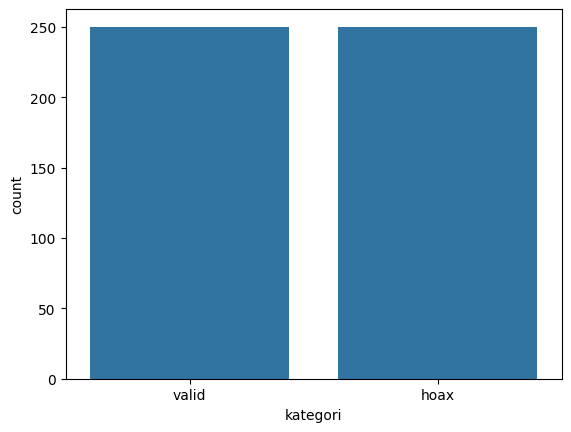

In [15]:
df[['berita', 'kategori', 'clean_berita']] = df['berita;kategori;clean_berita'].str.split(';', expand=True)
sns.countplot(x='kategori', data=df)
plt.show()

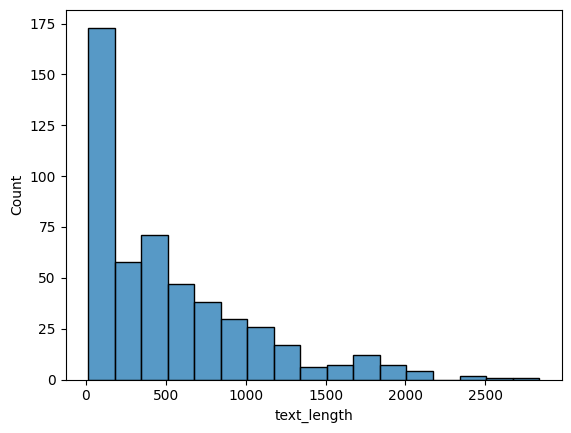

In [16]:
df['text_length'] = df['clean_berita'].astype(str).apply(len)

sns.histplot(df['text_length'])
plt.show()

# **5. Data Preprocessing**

Pada tahap ini, data preprocessing adalah langkah penting untuk memastikan kualitas data sebelum digunakan dalam model machine learning.

Jika Anda menggunakan data teks, data mentah sering kali mengandung nilai kosong, duplikasi, atau rentang nilai yang tidak konsisten, yang dapat memengaruhi kinerja model. Oleh karena itu, proses ini bertujuan untuk membersihkan dan mempersiapkan data agar analisis berjalan optimal.

Berikut adalah tahapan-tahapan yang bisa dilakukan, tetapi **tidak terbatas** pada:
1. Menghapus atau Menangani Data Kosong (Missing Values)
2. Menghapus Data Duplikat
3. Normalisasi atau Standarisasi Fitur
4. Deteksi dan Penanganan Outlier
5. Encoding Data Kategorikal
6. Binning (Pengelompokan Data)

Cukup sesuaikan dengan karakteristik data yang kamu gunakan yah. Khususnya ketika kami menggunakan data tidak terstruktur.

In [17]:
df.dropna(inplace=True)

In [18]:
df.drop_duplicates(inplace=True)

In [19]:
def case_folding(text):
    return text.lower()

df['clean_text'] = df['clean_berita'].apply(case_folding)

In [20]:
def clean_text(text):
    text = re.sub(r'http\S+', '', text)
    text = re.sub(r'\d+', '', text)
    text = text.translate(str.maketrans('', '', string.punctuation))
    return text

df['clean_text'] = df['clean_text'].apply(clean_text)

In [21]:
nltk.download('punkt_tab')
df['tokens'] = df['clean_text'].apply(word_tokenize)

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


In [22]:
stop_words = set(stopwords.words('indonesian'))

def remove_stopwords(tokens):
    return [word for word in tokens if word not in stop_words]

df['tokens'] = df['tokens'].apply(remove_stopwords)

In [23]:
df['final_text'] = df['tokens'].apply(lambda x: ' '.join(x))

**TF-IDF**

In [24]:
tfidf = TfidfVectorizer(max_features=5000)

X = tfidf.fit_transform(df['final_text'])

**LABEL ENCODING**

In [25]:
encoder = LabelEncoder()

y = encoder.fit_transform(df['kategori'])

**TRAIN TEST SPLIT**

In [26]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

**SAVE PREPROCESSING DATASET**

In [29]:
import os

processed_df = pd.DataFrame({
    'text': df['final_text'],
    'label': y
})

os.makedirs('preprocessing', exist_ok=True)

processed_df.to_csv(
    'preprocessing/dataset_preprocessing.csv',
    index=False
)

In [34]:
!python preprocessing/automate_fayza.py
print("Preprocessing selesai!")

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
Preprocessing selesai!
